# Result | Reward performance timescales {#sec-results-reward-performance-timescales}

Here, we compute and visualize the timescales required to reach almost the rewards of the final strategies across different levels of environmental uncertainty. We start by importing the required packages, defining some configurations and obtaining the required simulation data.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
plt.rcParams['text.usetex'] = True

from collections import namedtuple

from _code.UncertainDecisionProblem import \
    SingleAgentUncertainDecisionProblem, TwoAgentUncertainDecisionProblem

from _code.LearningDynamics import LearningAgents, ModelFreeAgents
from _code.SimulationScripts import _transform_tensor_into_hash
from _code.ObtainNoiseVariationResults import lowlevel_datadictionary, noise_levels

In [2]:
# Color palette (Okabe-Ito — colorblind-safe)
COLOR_SINGLE = "#0072B2"  # blue — single-agent environment
COLOR_SOCIAL = "#D55E00"  # vermillion — two-agent environment
COLOR_ACROSS = "#009E73"  # bluish green — time for two agents to match single-agent performance

In [3]:
Aprobabilities = [0.5, 0.52, 0.55, 0.58, 0.6, 0.7, 0.9]  

#### Compute reward trajectory function

We start by creating a function to compute trajectories that show how the average reward evolves over time, starting from a uniformly random initial strategy.

In [4]:
def compute_reward_trajectory(AgentClass, EnvClass, 
                              NoiseLevel, probabilityA=0.5,
                              maxT=100000, verbose=True):
    
    envparams = dict(noiselevel=NoiseLevel, 
                     probabilityA=probabilityA, 
                     likelydistance=0.5)

    if verbose:
        print(f"{AgentClass.__name__} in {EnvClass.__name__}"
              f" with Noiselevel: {NoiseLevel:.5f}", end=" ")

    env = EnvClass(**envparams)
    maei = AgentClass(env, learning_rates=0.25)

    Xioa = maei.zero_intelligence_policy()
    Xtioa, fpr = maei.trajectory(Xioa, Tmax=maxT, tolerance=10e-7)
    if verbose:
        print(f"FPR: {fpr}", end="\r")
    Rti = np.array([maei.Ri(Xioa) for Xioa in Xtioa])
    
    result = namedtuple("Result", ["Rti", "Xtioa", "fpr"])
    return result(Rti=Rti, Xtioa=Xtioa, fpr=fpr)

For example,

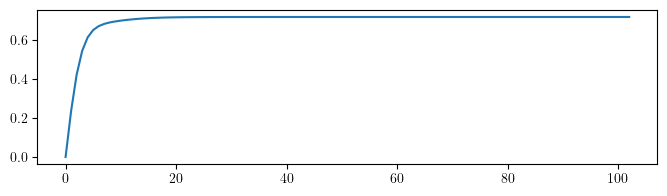

In [5]:
Rt = compute_reward_trajectory(LearningAgents, TwoAgentUncertainDecisionProblem, 
                                NoiseLevel=0.5, probabilityA=0.6)
fig = plt.figure(figsize=(8,2)); plt.plot(Rt.Rti.mean(-1));

#### Compute reward trajectories over noise levels

Now, we create a function to compute the reward trajectories over different levels of observational uncertainty for both the single-agent and two-agent environments.

In [6]:
def compute_reward_trajectories_over_noiselevels(
    AgentClass, EnvClass, NoiseLevels, probabilityA=0.5,
    maxT=100000):
    results = []
    for i, nl in enumerate(NoiseLevels):
        print(f"Computing for NoiseLevel={nl:.4f} ({(i+1)/len(NoiseLevels)*100:.1f}%)", end="\r")
        res = compute_reward_trajectory(
            AgentClass, EnvClass, nl, probabilityA=probabilityA, maxT=maxT, verbose=False)
        results.append(res.Rti)
    return results

The `obtain_` function chechks if the required data files already exist in the data directory. If they do, it loads them; otherwise, it computes the reward trajectories using the previously defined function and saves them for future use.

In [7]:
def obtain_reward_trajectories_over_noiselevels(
      AgentClass, EnvClass, NoiseLevels, ddir,
      probabilityA=0.5, maxT=100000):
      
      ## Create filename
      fn = (ddir +
            f"/RewardNOISVARI_"
            f"{AgentClass.__name__}_"
            f"{EnvClass.__name__}_"
            f"pA{probabilityA}_"
            f"Noises{_transform_tensor_into_hash(np.array(NoiseLevels))}_"
            f"maxT{maxT}"
            f".pkl")
      try:
            with open(fn, "rb") as f: Rnti = pickle.load(f)
            print("Loaded reward noise variation:", fn)

      except:
            print("Computing noise variation:", fn)
            Rnti = compute_reward_trajectories_over_noiselevels(
                  AgentClass, EnvClass, NoiseLevels, 
                  probabilityA=probabilityA, maxT=maxT)
            
            with open(fn, "wb") as f: pickle.dump(Rnti, f)
            with open(fn, "rb") as f: Rnti = pickle.load(f)
                  
      return Rnti

### Heavy computation

The following code cell obtains (i.e., computes or loads) all the required reward trajectory data for both the single-agent and two-agent environments across different levels of observational uncertainty.

In [8]:
#| output: false
Rnti = dict()
for Akey, AgentClass in zip(["MBA", "MFA"], [LearningAgents, ModelFreeAgents]):
    for pA in Aprobabilities:
        for Ekey, EnvClass in zip(["TAE", "SAE"], [TwoAgentUncertainDecisionProblem, SingleAgentUncertainDecisionProblem]):
        
            individual_Rnti = obtain_reward_trajectories_over_noiselevels(
                AgentClass, EnvClass, noise_levels, 
                probabilityA=pA, ddir=lowlevel_datadictionary)

            Rnti[(Akey, Ekey, pA)] = individual_Rnti    

Loaded reward noise variation: /Users/wolf/Downloads/L2SocialData/RewardNOISVARI_LearningAgents_TwoAgentUncertainDecisionProblem_pA0.5_Noises7752999609125433264_maxT100000.pkl
Loaded reward noise variation: /Users/wolf/Downloads/L2SocialData/RewardNOISVARI_LearningAgents_SingleAgentUncertainDecisionProblem_pA0.5_Noises7752999609125433264_maxT100000.pkl
Loaded reward noise variation: /Users/wolf/Downloads/L2SocialData/RewardNOISVARI_LearningAgents_TwoAgentUncertainDecisionProblem_pA0.52_Noises7752999609125433264_maxT100000.pkl
Loaded reward noise variation: /Users/wolf/Downloads/L2SocialData/RewardNOISVARI_LearningAgents_SingleAgentUncertainDecisionProblem_pA0.52_Noises7752999609125433264_maxT100000.pkl
Loaded reward noise variation: /Users/wolf/Downloads/L2SocialData/RewardNOISVARI_LearningAgents_TwoAgentUncertainDecisionProblem_pA0.55_Noises7752999609125433264_maxT100000.pkl
Loaded reward noise variation: /Users/wolf/Downloads/L2SocialData/RewardNOISVARI_LearningAgents_SingleAgentUnce

### Results

We are finally ready to visualize the timescales required to reach almost the rewards of the final strategies across different levels of environmental uncertainty. We start by defining a function to plot an overview how the two different learning dynamics compare across uncertainty levels.

In [9]:
def overview_plot(plot_func, ylabel, 
                  MFAylim=(None, None), MBAylim=(None, None), **pfunc_kwargs):
    fsf = 0.50

    nr_pA = len(Aprobabilities)
    fig, axes = plt.subplots(nr_pA, 2, figsize=(fsf*16, fsf*20))


    for i, axs in enumerate(axes):
        pA = Aprobabilities[i]
        
        # # data plotting
        plot_func(
            Rnti, noise_levels, Akey="MFA", pA=pA, ax=axs[0], **pfunc_kwargs)
        plot_func(
            Rnti, noise_levels, Akey="MBA", pA=pA, ax=axs[1], **pfunc_kwargs)

        su = np.round(pA, 2)
        axs[0].set_ylabel(f"$p_B={1-su:.2f}$"); axs[1].set_ylabel("");
        axs[0].set_ylim(MFAylim), axs[1].set_ylim(MBAylim)

        axs[0].xaxis.set_minor_locator(MultipleLocator(0.2))
        axs[1].xaxis.set_minor_locator(MultipleLocator(0.2))
        axs[0].grid(True, which='major', axis='both', alpha=0.5)
        axs[1].grid(True, which='major', axis='both', alpha=0.5)
        
    for i in range(nr_pA-1):
        axes[i,0].set_xticklabels(""); axes[i,0].set_xlabel("")
        axes[i,1].set_xticklabels(""); axes[i,1].set_xlabel("")

    # Add global y label
    plt.gca().annotate(ylabel, (0.01, 0.45),
                    xycoords='figure fraction',
                    rotation=90, ha='left', va='center', fontsize=13)
    axes[0,0].set_title("Model-Free Agents", fontsize=13)
    axes[0,1].set_title("Model-Based Agents", fontsize=13);
    
    plt.subplots_adjust(hspace=0.08)

#### Percentange length

First, we define a function the returns the number of time steps required to reach a certain percentage of the final reward.

In [10]:
def find_percentage_length(Rti, percentage):
    final_reward = Rti[-1].mean()
    threshold = percentage * final_reward
    try:
        length = min(np.where(Rti.mean(-1) >= threshold)[0])
    except ValueError:
        length = len(Rti)
    return length

This function is then used to visualize how quickly the different learning dynamics reach various percentages of the final reward across different levels of environmental uncertainty.

In [11]:
def plot_percentage_convergence_lengths(Rnti, noise_levels, ax=None,
                                        Akey="MBA", pA=0.5, 
                                        percentages=[0.9, 0.99, 0.999],
                                        ylogscale=False):
    if ax is None: ax = plt.gca()   
    
    TAE_lengths = []
    SAE_lengths = []
    for perc in percentages:
        TAE_lengths.append([find_percentage_length(Rti, perc)
                            for Rti in Rnti[(Akey, "TAE", pA)]])
        SAE_lengths.append([find_percentage_length(Rti, perc)
                            for Rti in Rnti[(Akey, "SAE", pA)]])
    
    ax.fill_between(noise_levels, SAE_lengths[0], SAE_lengths[-1], color=COLOR_SINGLE,
                    alpha=0.2, label="Single-Agent range")
    ax.fill_between(noise_levels, TAE_lengths[0], TAE_lengths[-1], color=COLOR_SOCIAL,
                    alpha=0.2, label="Two-Agent range")
    
    # # Plot the highest percentage lines for reference
    # percentage = percentages[-1]
    ax.plot(noise_levels, SAE_lengths[1], c=COLOR_SINGLE)
    ax.plot(noise_levels, TAE_lengths[1], c=COLOR_SOCIAL)
    ax.set_xlabel('Observational uncertainty $\\sigma$')
    # ax.set_ylabel(f"Reward Convergence Length to {percentage*100:.0f}% of final reward (timesteps)")    
    xlim=[-0.05, max(noise_levels)+0.05]
    ax.set_xlim(xlim)
    if ylogscale: ax.set_yscale("log")
    ax.grid(True, which='major', axis='both', alpha=0.5)

For example,

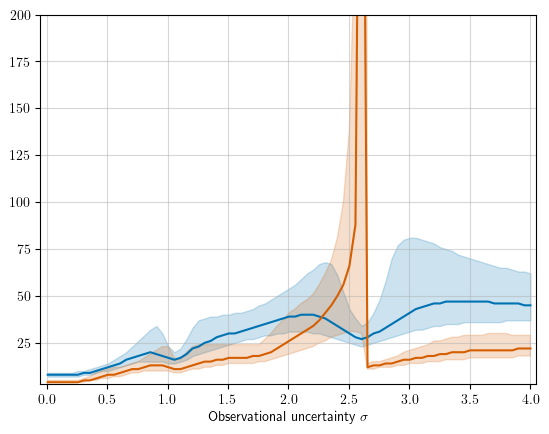

In [12]:
#| fig-cap: Example of reward-percentage convergence lengths visualization.
plot_percentage_convergence_lengths(
    Rnti, noise_levels, Akey="MBA", pA=0.6, percentages=[0.925, 0.95, 0.975])
plt.ylim(3, 200);

Inserting this visualization function into the overview plot yields,

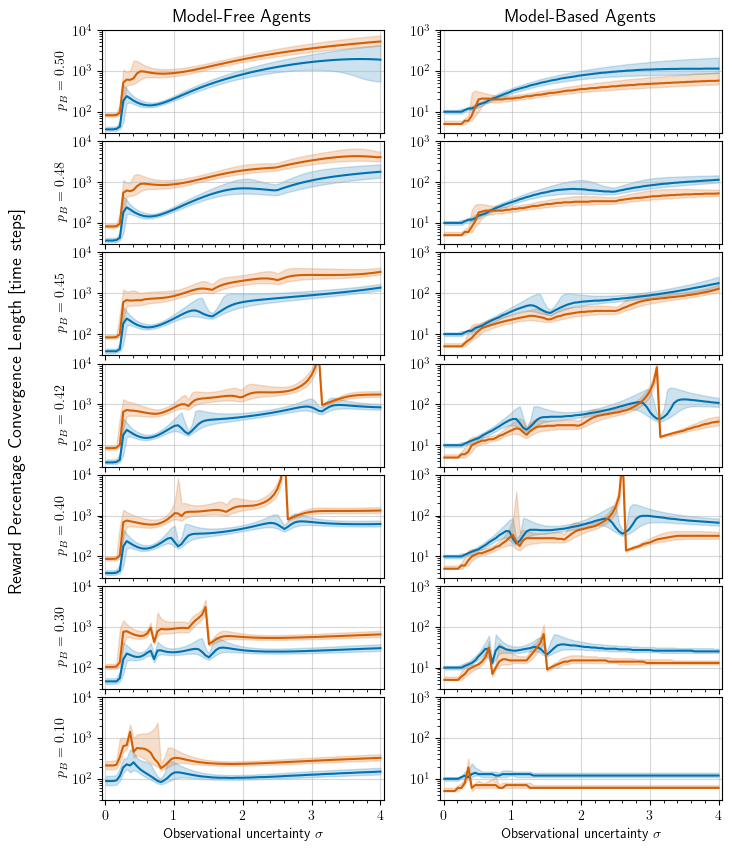

In [13]:
#| fig-cap: Overview of the learning time steps required until 98\% ($\pm$ 1\%) of the final reward at strategy convergence is reached versus observational uncertainty $\sigma$ for all state uncertainties $p_B$ investigated. The left panels show model-free learning dynamics, the right panels show model-based ones.
overview_plot(plot_percentage_convergence_lengths,
              ylabel="Reward Percentage Convergence Length [time steps]",
              MFAylim=(30, 10000),
              MBAylim=(3, 1000),
              percentages=[0.97, 0.98, 0.99],
              ylogscale=True
              )

#### Compared perfomance length

We also visualize the time steps required for the two-agent learners to reach the respective performance levels of the single-agent learner. To do so, we define a function that computes the time steps required to reach a specific threshold reward value.

In [14]:
def find_comparison_length(Rti, threshold):
    try:
        length = min(np.where(Rti.mean(-1) >= threshold)[0])
    except ValueError:
        length = np.inf
    return length

We insert the above function into an explicit comparison function that visualizes the time steps required for the two-agent learners to reach the respective performance levels of the single-agent learner,

In [15]:
def plot_compared_percentage_convergence_lengths(
    Rnti, noise_levels, ax=None, Akey="MBA", pA=0.5, 
    percentages=[0.9, 0.99, 0.999], ylogscale=False):
    if ax is None: ax = plt.gca()   
    
    lengthss = []
    
    for perc in percentages:
        
        lengths = []
        for n, Rti in enumerate(Rnti[(Akey, "TAE", pA)]):
            threshold = perc*Rnti[(Akey, "SAE", pA)][n][-1].mean(-1)
            lengths.append(find_comparison_length(Rti, threshold))

        lengthss.append(lengths)
    
    ax.fill_between(noise_levels, lengthss[0], lengthss[-1], color=COLOR_ACROSS, 
                    alpha=0.2)
    
    ax.plot(noise_levels, lengthss[1], c=COLOR_ACROSS)
    ax.set_xlabel('Observational uncertainty $\\sigma$')
    # ax.set_ylabel(f"Reward Convergence Length to {percentage*100:.0f}% of final reward (timesteps)")    
    xlim=[-0.05, max(noise_levels)+0.05]
    ax.set_xlim(xlim)
    if ylogscale: ax.set_yscale("log")

This function yields, for example,

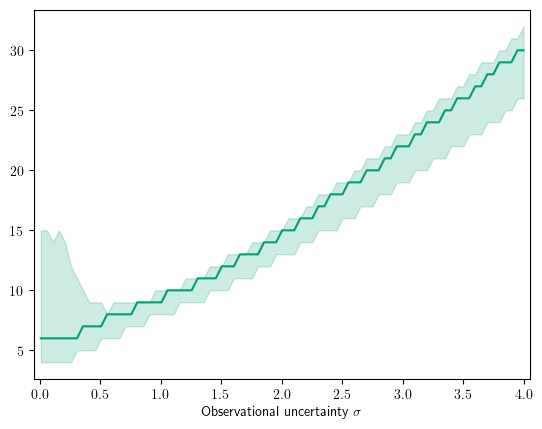

In [16]:
#| fig-cap: Example of compared reward-percentage convergence lengths visualization.
plot_compared_percentage_convergence_lengths(
    Rnti, noise_levels, Akey="MBA", pA=0.5, percentages=[0.95, 0.99, 1.0])

and across all state uncertainties and agent models,

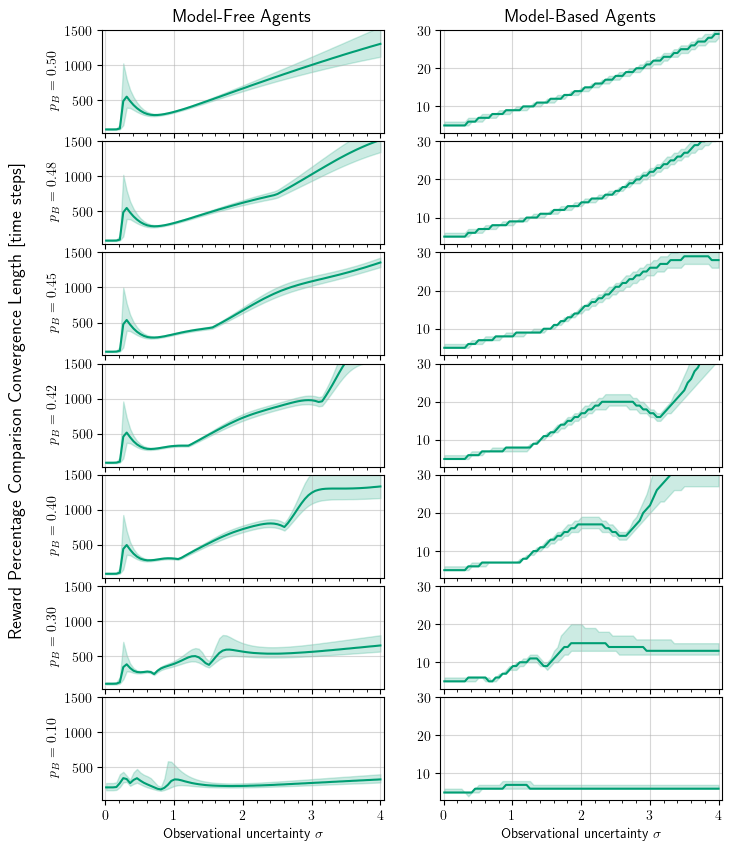

In [17]:
#| fig-cap: Overview of the learning time steps required until 98\% ($\pm$ 1\%) of the final reward of the single-agent learner at strategy convergence is reached by the two-agent learners versus observational uncertainty $\sigma$ for all state uncertainties $p_B$ investigated. The left panels show model-free learning dynamics, the right panels show model-based ones.
overview_plot(plot_compared_percentage_convergence_lengths,
              ylabel="Reward Percentage Comparison Convergence Length [time steps]",
              MFAylim=(30, 1500),
              MBAylim=(3, 30),
              percentages=[0.97, 0.98, 0.99],
              # ylogscale=True
              )

#### Combined percentance lengths

Last, we create a function to plot both measures,

In [18]:
def plot_percentage_comparison_convergence_lengths(Rnti, noise_levels, ax=None,
                                        Akey="MBA", pA=0.5, 
                                        percentages=[0.9, 0.99, 0.999],
                                        ylogscale=False):
    if ax is None: ax = plt.gca()  
      
    TAE_lengths = []
    SAE_lengths = []
    com_lengths = []
    for perc in percentages:

        com_lens = []
        for n, Rti in enumerate(Rnti[(Akey, "TAE", pA)]):
            threshold = perc*Rnti[(Akey, "SAE", pA)][n][-1].mean(-1)
            com_lens.append(find_comparison_length(Rti, threshold))
        com_lengths.append(com_lens)

        TAE_lengths.append([find_percentage_length(Rti, perc)
                            for Rti in Rnti[(Akey, "TAE", pA)]])

        SAE_lengths.append([find_percentage_length(Rti, perc)
                            for Rti in Rnti[(Akey, "SAE", pA)]])
        
    ax.fill_between(noise_levels, SAE_lengths[0], SAE_lengths[-1], color=COLOR_SINGLE,
                    alpha=0.2, label="Single-Agent range")
    ax.fill_between(noise_levels, TAE_lengths[0], TAE_lengths[-1], color=COLOR_SOCIAL,
                    alpha=0.2, label="Two-Agent range")
    
    ax.fill_between(noise_levels, com_lengths[0], com_lengths[-1], color=COLOR_ACROSS, 
                    alpha=0.2)
    
    # # Plot the highest percentage lines for reference
    # percentage = percentages[-1]
    ax.plot(noise_levels, SAE_lengths[1], c=COLOR_SINGLE)
    ax.plot(noise_levels, TAE_lengths[1], c=COLOR_SOCIAL)
    ax.plot(noise_levels, com_lengths[1], c=COLOR_ACROSS)

    ax.set_xlabel('Observational uncertainty $\\sigma$')
    # ax.set_ylabel(f"Reward Convergence Length to {percentage*100:.0f}% of final reward (timesteps)")    
    xlim=[-0.05, max(noise_levels)+0.05]
    ax.set_xlim(xlim)
    if ylogscale: ax.set_yscale("log")
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))

It yields, for example,

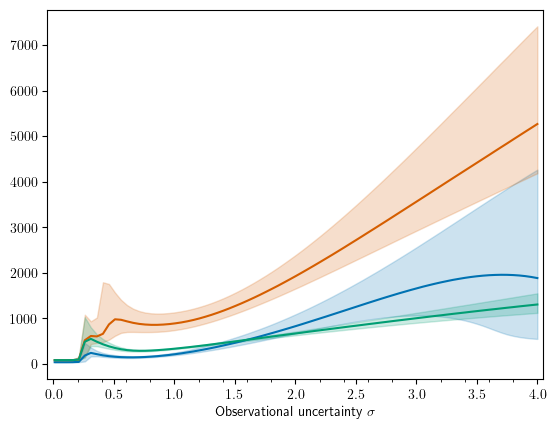

In [19]:
#| fig-cap: Example of combined reward-percentage convergence lengths visualization.
plot_percentage_comparison_convergence_lengths(
    Rnti, noise_levels, Akey="MFA", pA=0.5, percentages=[0.97, 0.98, 0.99])

and across all state uncertainties and agent models,

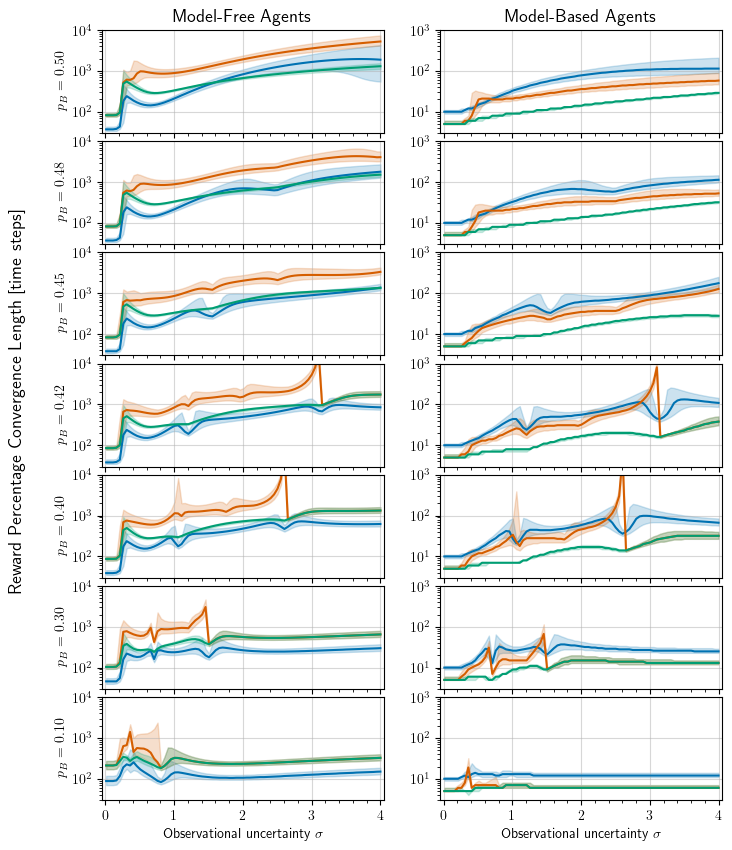

In [20]:
#| fig-cap: Overview of the learning time steps required until 98\% ($\pm$ 1\%) of the final reward versus observational uncertainty $\sigma$ for all state uncertainties $p_B$ investigated. The left panels show model-free learning dynamics, the right panels show model-based ones. Blue colors indicate the single-agent environment, vermillion colors indicate the two-agent environment. The green color indicates the time steps required for the two learners to reach the respective performance level of the single agent.
overview_plot(plot_percentage_comparison_convergence_lengths,
              ylabel="Reward Percentage Convergence Length [time steps]",
              MFAylim=(30, 10000),
              MBAylim=(3, 1000),
              percentages=[0.97, 0.98, 0.99],
              ylogscale=True
              )

#### Main text figure

Again, we define the two helper functions to plot vertical lines to better visualize the critical levels of observational uncertainty where strategy transitions occur.

In [21]:
def plot_vertical_line_at_noise_level(ax, noise_level, ls='-'):
    ax.plot([noise_level, noise_level], ax.get_ylim(), ls, color='gray', lw=1.0)

In [22]:
def plot_vertical_lines_at_all_axes(axes, noise_level, ls='-'):
    for ax in axes: plot_vertical_line_at_noise_level(ax, noise_level, ls)

Putting everything together, we create the Figure 5 of the main text showing the learning time steps required to reach almost the rewards of the final strategies across different levels of environmental uncertainty.

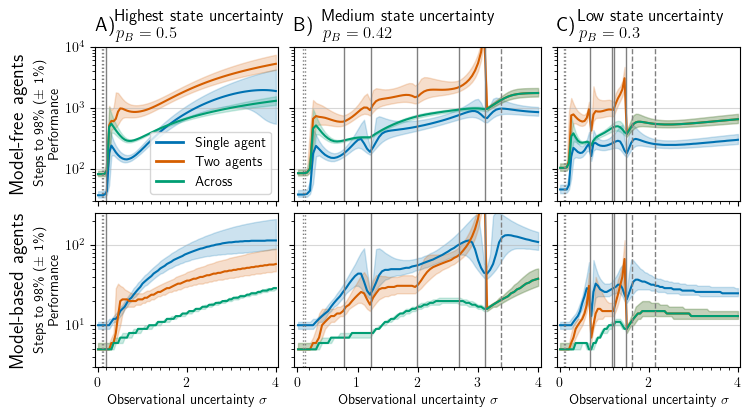

In [23]:
#| fig-cap: Figure 5 of the main text showing the learning time steps required to reach almost the rewards of the final strategies.
fsf = 0.26
fig = plt.figure(figsize=(fsf*32, fsf*16))

gs = GridSpec(2, 3, hspace=0.08, wspace=0.08,
              height_ratios=[1, 1], width_ratios=[1,1.35,1])

titleparams = dict(loc="left", x=0.11)
ABCparams = dict(xy=(0.0, 1.2), ha='left', va='top',
                 xycoords='axes fraction', fontsize=14, fontweight='bold')
agentmodelparams = dict(
    xy=(-0.42, 0.5), rotation=90, fontsize=14, ha='center',
    va='center', xycoords='axes fraction', fontweight='bold') 
plotparams = dict(percentages=[0.97, 0.98, 0.99], ylogscale=True)
MFAylim = (30, 10000); MBAylim = (3, 250)

## 1 | Highest state uncertainty (p(A)=0.5)
ax_MFA_high = fig.add_subplot(gs[0, 0]); 
ax_MFA_high.set_title("Highest state uncertainty\n$p_B=0.5$", **titleparams)
ax_MFA_high.annotate("A)", **ABCparams)
plot_percentage_comparison_convergence_lengths(
    Rnti, noise_levels, Akey="MFA", pA=0.5, **plotparams)
ax_MFA_high.set_xlabel(""); ax_MFA_high.set_xticklabels([])
ax_MFA_high.set_ylabel("Steps to 98\\% ($\\pm$ 1\\%)\nPerformance")
ax_MFA_high.annotate("Model-free agents", **agentmodelparams)
ax_MFA_high.set_ylim(MFAylim)
plt.gca().grid(True, which='major', axis='y', alpha=0.5)

ax_MBA_high = fig.add_subplot(gs[1, 0]);
plot_percentage_comparison_convergence_lengths(
    Rnti, noise_levels, Akey="MBA", pA=0.5, **plotparams)
ax_MBA_high.annotate("Model-based agents", **agentmodelparams)
ax_MBA_high.set_ylim(MBAylim)
ax_MBA_high.set_ylabel("Steps to 98\\% ($\\pm$ 1\\%)\nPerformance")
plt.gca().grid(True, which='major', axis='y', alpha=0.5)

axes = [ax_MFA_high, ax_MBA_high]
plot_vertical_lines_at_all_axes(axes, 0.09, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.13, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.19)


## 2 | Medium state uncertainty (p(A)=0.6)
ax_MFA_mid = fig.add_subplot(gs[0, 1]);
ax_MFA_mid.set_title("Medium state uncertainty\n$p_B=0.42$", **titleparams)
ax_MFA_mid.annotate("B)", **ABCparams)
plot_percentage_comparison_convergence_lengths(
    Rnti, noise_levels, Akey="MFA", pA=0.58, **plotparams)
ax_MFA_mid.set_ylabel(""); ax_MFA_mid.set_yticklabels([])
ax_MFA_mid.set_xlabel(""); ax_MFA_mid.set_xticklabels([])
ax_MFA_mid.set_ylim(MFAylim)
plt.gca().grid(True, which='major', axis='y', alpha=0.5)

ax_MBA_mid = fig.add_subplot(gs[1, 1]);
plot_percentage_comparison_convergence_lengths(
    Rnti, noise_levels, Akey="MBA", pA=0.58, **plotparams)
ax_MBA_mid.set_ylabel(""); ax_MBA_mid.set_yticklabels([])
ax_MBA_mid.set_ylim(MBAylim)
plt.gca().grid(True, which='major', axis='y', alpha=0.5)

axes = [ax_MFA_mid, ax_MBA_mid]
plot_vertical_lines_at_all_axes(axes, 0.09, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.13, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.78)
plot_vertical_lines_at_all_axes(axes, 1.22)
plot_vertical_lines_at_all_axes(axes, 1.98)
plot_vertical_lines_at_all_axes(axes, 2.68)
plot_vertical_lines_at_all_axes(axes, 3.11)
plot_vertical_lines_at_all_axes(axes, 3.38, ls="--")

## 3 | Lowest state uncertainty (p(A)=0.7)
ax_MFA_low = fig.add_subplot(gs[0, 2]);
ax_MFA_low.set_title("Low state uncertainty\n$p_B=0.3$", **titleparams)
ax_MFA_low.annotate("C)", **ABCparams)
plot_percentage_comparison_convergence_lengths(
    Rnti, noise_levels, Akey="MFA", pA=0.7, **plotparams)
ax_MFA_low.set_ylabel(""); ax_MFA_low.set_yticklabels([])
ax_MFA_low.set_xlabel(""); ax_MFA_low.set_xticklabels([])
ax_MFA_low.set_ylim(MFAylim)
plt.gca().grid(True, which='major', axis='y', alpha=0.5)

ax_MBA_low = fig.add_subplot(gs[1, 2]);
plot_percentage_comparison_convergence_lengths(
    Rnti, noise_levels, Akey="MBA", pA=0.7, **plotparams)
ax_MBA_low.set_ylabel(""); ax_MBA_low.set_yticklabels([]);
ax_MBA_low.set_ylim(MBAylim)
plt.gca().grid(True, which='major', axis='y', alpha=0.5)

axes = [ax_MFA_low, ax_MBA_low]
plot_vertical_lines_at_all_axes(axes, 0.09, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.13, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.68)
plot_vertical_lines_at_all_axes(axes, 1.18)
plot_vertical_lines_at_all_axes(axes, 1.23)
plot_vertical_lines_at_all_axes(axes, 1.48)
plot_vertical_lines_at_all_axes(axes, 1.63, ls="--")
plot_vertical_lines_at_all_axes(axes, 2.13, ls="--")


# Legend
legend_elements = [Line2D([0], [0], color=COLOR_SINGLE, lw=2, label='Single agent'),
                   Line2D([0], [0], color=COLOR_SOCIAL, lw=2, label='Two agents'),
                   Line2D([0], [0], color=COLOR_ACROSS, lw=2, label='Across')]  
ax_MFA_high.legend(handles=legend_elements, loc='lower right')

plt.savefig("./_figs/RewardPerformanceSteps.png", bbox_inches='tight', dpi=300)